The purpose of this file is to analyze and detect an up coming recession based on the data pulled from https://fred.stlouisfed.org/

In [946]:
import matplotlib.pyplot as plt
import pandas as pd
from fredapi import Fred
import datetime
import numpy as np
import random

FRED_API_KEY = "612c90fb30af12767bbcaf9513bac5ed"
fred = Fred(api_key=FRED_API_KEY)

# TODO: use pretty, interactive graph library instead of matplotlib

In [947]:
def get_recession_data() -> pd.DataFrame:
    """
    Creates the recession dates dataframe

    Returns:
    - pd.DataFrame: The recession dates dataframe.
    """
    df_recession = pd.read_csv("data/USREC.csv")
    df_recession = df_recession.rename(columns={"USREC": "recession", "DATE": "date"})
    df_recession["date"] = pd.to_datetime(df_recession["date"])
    df_recession = df_recession.set_index("date")
    return df_recession


df = get_recession_data()
df

,recession
date,
1854-12-01,1
1855-01-01,0
1855-02-01,0
1855-03-01,0
1855-04-01,0
...,...
2023-06-01,0
2023-07-01,0
2023-08-01,0


In [948]:
def merge_recession_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Creates the recession dates dataframe and
    modifies the start and end dates to match the dataframe passed in.

    Parameters:
    - df (pd.DataFrame): The input dataframe containing the data.

    Returns:
    - pd.DataFrame: The modified recession dates dataframe.
    """

    df_recession = get_recession_data()

    # Make sure that both dataframes start and end at the same index
    start_date = max(df.index.min(), df_recession.index.min())
    end_date = min(df.index.max(), df_recession.index.max())

    # df = df.loc[start_date:end_date]
    df_recession = df_recession.loc[start_date:end_date]

    return df_recession

In [949]:
def get_data_after_date(
    data: pd.DataFrame, years: int = 1, days: int = 0
) -> pd.DataFrame:
    data_clean = data.dropna()

    # get the most recent date, convert to datetime obj and then get 1 year ago date
    most_recent_dt = data_clean.index[-1]
    one_year_ago_dt = most_recent_dt - pd.DateOffset(years=years, days=days)
    return data_clean.loc[one_year_ago_dt:]

In [950]:
def set_recession_values(value, min_value, max_value):
    # if min_value < 0:
    #     value = min_value
    if value > 0:
        value = max_value
    return value
    

def plot_it(
    data_df: pd.Series,
    title: str,
    figsize: tuple[int, int] = (15, 5),
    plot_recession_dates: bool = False,
) -> None:
    fig, ax = plt.subplots(figsize=figsize)

    if plot_recession_dates:
        recession_df = get_recession_data()

        # join the two dataframes and remove every date that doesn't start at the beginning of the month (1-1-1990)
        recession_df = recession_df.join(data_df, on="date")
        recession_df = recession_df.dropna()
        recession_df = recession_df.drop("data", axis=1)

        data_df = data_df.join(recession_df, on="date").dropna()
        data_df = data_df.drop('recession', axis=1)

        # normalize recession dates to min and max of the data passed in
        # min_value = 0

        # if data_df['data'].min() < min_value:
        #     print(type(min_value))
        #     min_value = data_df['data'].min()

        min_value = data_df['data'].min()
        max_value = data_df["data"].max()

        print(min_value, max_value)
        print(recession_df)
        recession_df["recession"] = recession_df["recession"].apply(
            set_recession_values, args=(min_value, max_value)
        )

        # FIXME: what if both values are below 0?
        # FIXME: treasury values go below 0 but this code doesn't account for that
        data_df.plot(ax=ax, alpha=0.5, color="blue")
        recession_df.plot.area(ax=ax, alpha=0.5, color="gray")

        print(recession_df)

    # data_df.plot(ax=ax, alpha=0.5, color="blue")
    # print(data_df)
    plt.title(title)
    plt.show()

In [951]:
def plot_data(symbol, title, years, plot_recession_dates=True):
    data = fred.get_series(symbol)
    result = get_data_after_date(data, years=years)

    if isinstance(result, pd.Series):
        result = pd.DataFrame(result).reset_index()
        result.columns = ['date', 'data']
        result = result.set_index('date')

    plot_it(result, title, plot_recession_dates=plot_recession_dates)

In [952]:
def test_recession_dates(use_random_timeframe: bool = False) -> None:
    """
    Ensures that data can be plotted alongside of the recession dates in one figure
    """

    end = datetime.datetime.now()
    date = datetime.datetime(1985, 1, 1)
    rec_df = get_recession_data()

    if use_random_timeframe:
        # pick a random date in the available data
        # get the first date in the recession dates
        res = random.choices(rec_df.index, k=2)
        rand_years = [i.year for i in res]
        start_year, end_year = min(rand_years), max(rand_years)
        date = datetime.datetime(start_year, 1, 1)
        end = datetime.datetime(end_year, 1, 1)

    date_list = [date]

    while date < end:
        date += datetime.timedelta(days=1)
        date_list.append(date)

    rand_data = np.random.uniform(low=0, high=1, size=len(date_list))
    data_df = pd.DataFrame({"date": date_list, "data": rand_data})

    # Tests if the recession dates were plotted correctly
    data_df = data_df.set_index("date")

    # combine the df with the recession dates
    plot_it(data_df, "Data & Recession Dates", plot_recession_dates=True)


# test_recession_dates(use_random_timeframe=True)

0.05 19.1
            recession
date                 
1954-07-01          0
1954-08-01          0
1954-09-01          0
1954-10-01          0
1954-11-01          0
...               ...
2023-06-01          0
2023-07-01          0
2023-08-01          0
2023-09-01          0
2023-10-01          0

[832 rows x 1 columns]
            recession
date                 
1954-07-01        0.0
1954-08-01        0.0
1954-09-01        0.0
1954-10-01        0.0
1954-11-01        0.0
...               ...
2023-06-01        0.0
2023-07-01        0.0
2023-08-01        0.0
2023-09-01        0.0
2023-10-01        0.0

[832 rows x 1 columns]


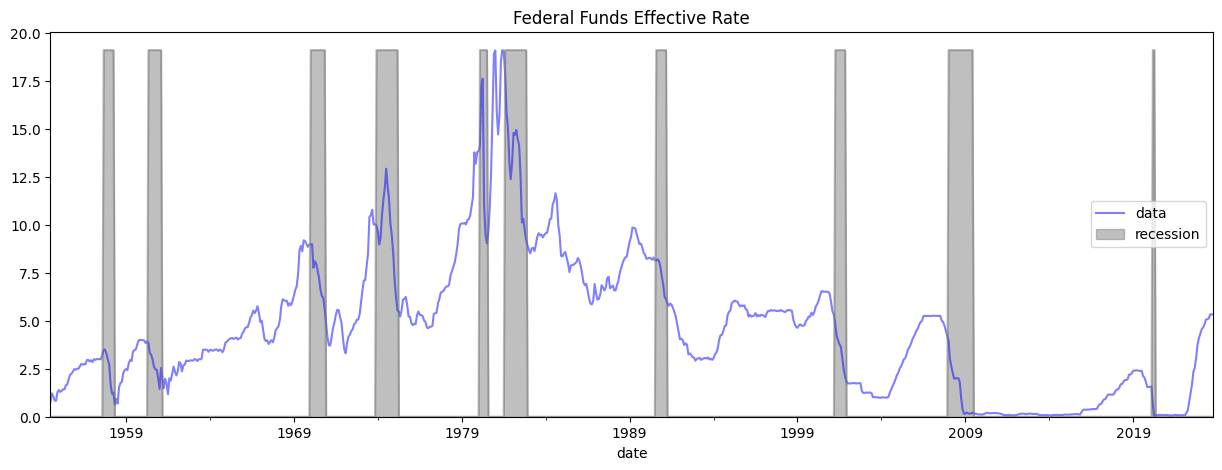

In [953]:
# """Federal Funds Effective Rate (FEDFUNDS)"""
plot_data("FEDFUNDS", "Federal Funds Effective Rate", years=70)

21708.16 22668.986
            recession
date                 
2021-10-01          0
2022-01-01          0
2022-04-01          0
2022-07-01          0
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
2023-10-01          0
            recession
date                 
2021-10-01          0
2022-01-01          0
2022-04-01          0
2022-07-01          0
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
2023-10-01          0


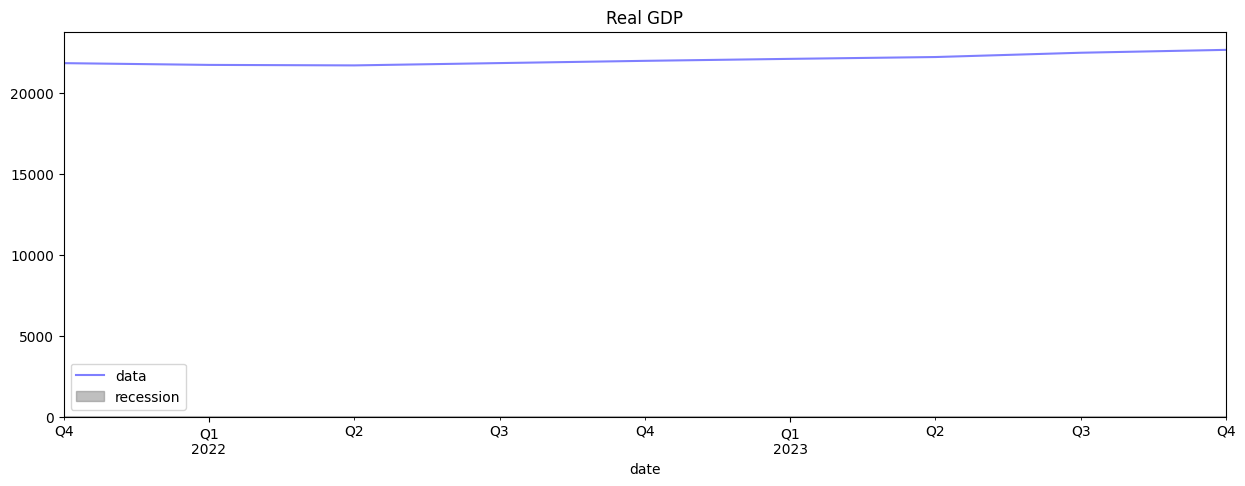

In [954]:
"""
GDP Contraction: One of the primary indicators is a decline in Gross Domestic Product (GDP),
which measures the total value of goods and services produced in a country.
A negative GDP growth for two consecutive quarters is often considered a technical recession.
"""
# Real Gross Domestic Product (GDPC1)
plot_data("GDPC1", "Real GDP", years=2)

3.4 4.0
            recession
date                 
2022-01-01          0
2022-02-01          0
2022-03-01          0
2022-04-01          0
2022-05-01          0
2022-06-01          0
2022-07-01          0
2022-08-01          0
2022-09-01          0
2022-10-01          0
2022-11-01          0
2022-12-01          0
2023-01-01          0
2023-02-01          0
2023-03-01          0
2023-04-01          0
2023-05-01          0
2023-06-01          0
2023-07-01          0
2023-08-01          0
2023-09-01          0
2023-10-01          0
            recession
date                 
2022-01-01          0
2022-02-01          0
2022-03-01          0
2022-04-01          0
2022-05-01          0
2022-06-01          0
2022-07-01          0
2022-08-01          0
2022-09-01          0
2022-10-01          0
2022-11-01          0
2022-12-01          0
2023-01-01          0
2023-02-01          0
2023-03-01          0
2023-04-01          0
2023-05-01          0
2023-06-01          0
2023-07-01          0
20

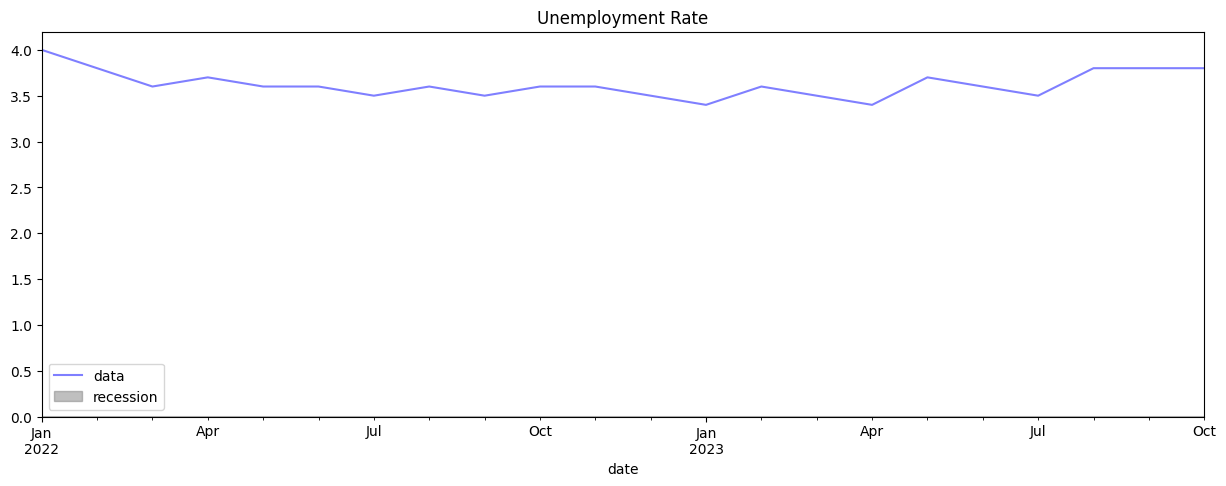

In [955]:
"""
Rising Unemployment: Job losses and rising unemployment rates are common
during a recession as businesses may cut costs by reducing their workforce.
"""
plot_data("UNRATE", "Unemployment Rate", years=2)

12228.3 18810.6
            recession
date                 
2020-01-01          0
2020-02-01          0
2020-03-01          1
2020-04-01          1
2020-05-01          0
2020-06-01          0
2020-07-01          0
2020-08-01          0
2020-09-01          0
2020-10-01          0
2020-11-01          0
2020-12-01          0
2021-01-01          0
2021-02-01          0
2021-03-01          0
2021-04-01          0
2021-05-01          0
2021-06-01          0
2021-07-01          0
2021-08-01          0
2021-09-01          0
2021-10-01          0
2021-11-01          0
2021-12-01          0
2022-01-01          0
2022-02-01          0
2022-03-01          0
2022-04-01          0
2022-05-01          0
2022-06-01          0
2022-07-01          0
2022-08-01          0
2022-09-01          0
2022-10-01          0
2022-11-01          0
2022-12-01          0
2023-01-01          0
2023-02-01          0
2023-03-01          0
2023-04-01          0
2023-05-01          0
2023-06-01          0
2023-07-01      

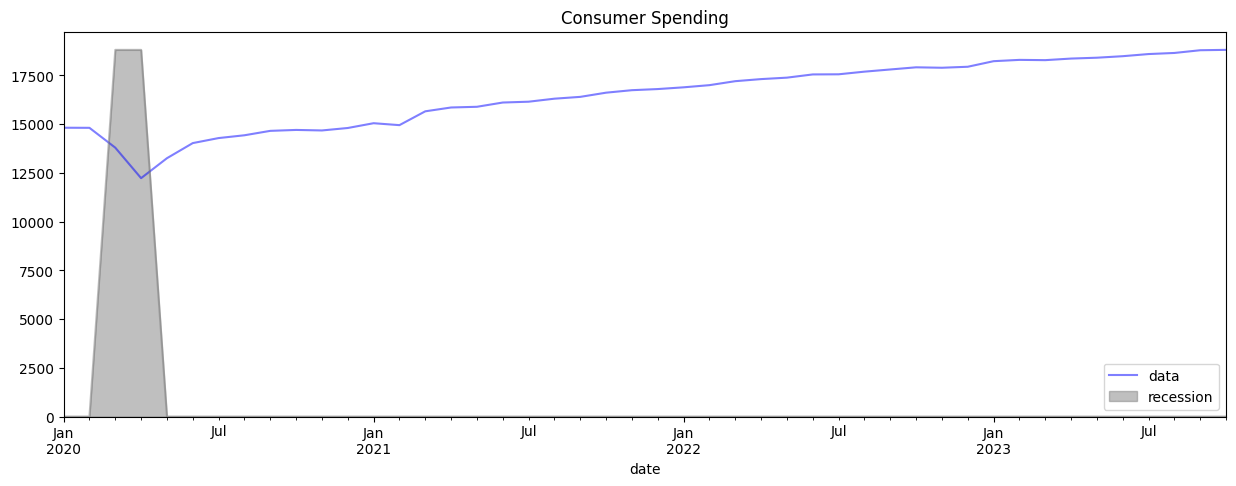

In [956]:
"""
Consumer spending tends to decrease during economic
downturns as people become more cautious about their finances.
This can impact various industries, especially retail.
"""
plot_data("PCE", "Consumer Spending", years=4)

84.5979 103.5283
            recession
date                 
2019-01-01          0
2019-02-01          0
2019-03-01          0
2019-04-01          0
2019-05-01          0
2019-06-01          0
2019-07-01          0
2019-08-01          0
2019-09-01          0
2019-10-01          0
2019-11-01          0
2019-12-01          0
2020-01-01          0
2020-02-01          0
2020-03-01          1
2020-04-01          1
2020-05-01          0
2020-06-01          0
2020-07-01          0
2020-08-01          0
2020-09-01          0
2020-10-01          0
2020-11-01          0
2020-12-01          0
2021-01-01          0
2021-02-01          0
2021-03-01          0
2021-04-01          0
2021-05-01          0
2021-06-01          0
2021-07-01          0
2021-08-01          0
2021-09-01          0
2021-10-01          0
2021-11-01          0
2021-12-01          0
2022-01-01          0
2022-02-01          0
2022-03-01          0
2022-04-01          0
2022-05-01          0
2022-06-01          0
2022-07-01     

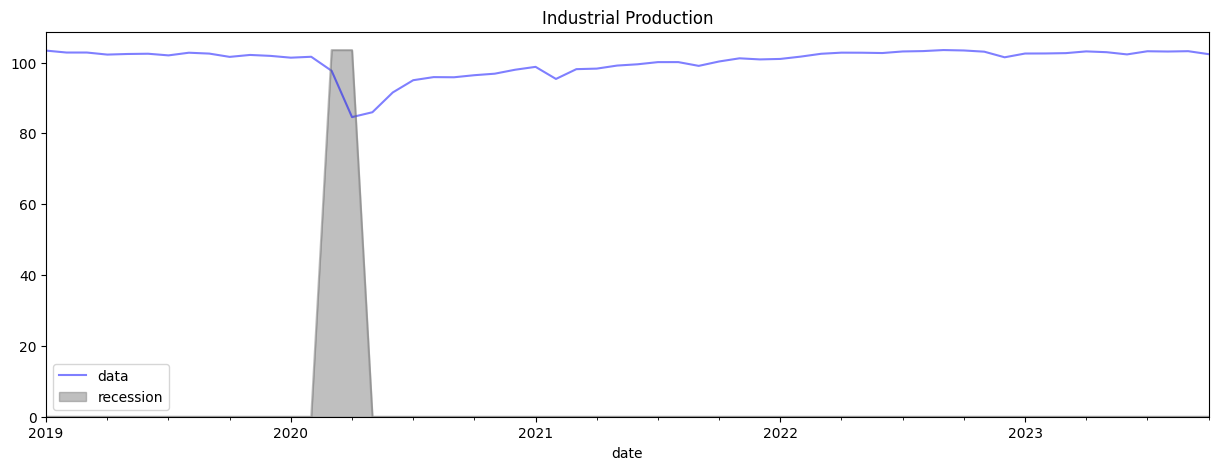

In [957]:
"""
Reduced Industrial Production: A decrease in the production of goods and services
by industries is a clear sign of economic contraction.
This can be measured by the Industrial Production Index.
"""
plot_data("INDPRO", "Industrial Production", years=5)

3825.33 4576.73
            recession
date                 
2022-03-01          0
2022-04-01          0
2022-06-01          0
2022-07-01          0
2022-08-01          0
2022-09-01          0
2022-11-01          0
2022-12-01          0
2023-02-01          0
2023-03-01          0
2023-05-01          0
2023-06-01          0
2023-08-01          0
2023-09-01          0
            recession
date                 
2022-03-01          0
2022-04-01          0
2022-06-01          0
2022-07-01          0
2022-08-01          0
2022-09-01          0
2022-11-01          0
2022-12-01          0
2023-02-01          0
2023-03-01          0
2023-05-01          0
2023-06-01          0
2023-08-01          0
2023-09-01          0


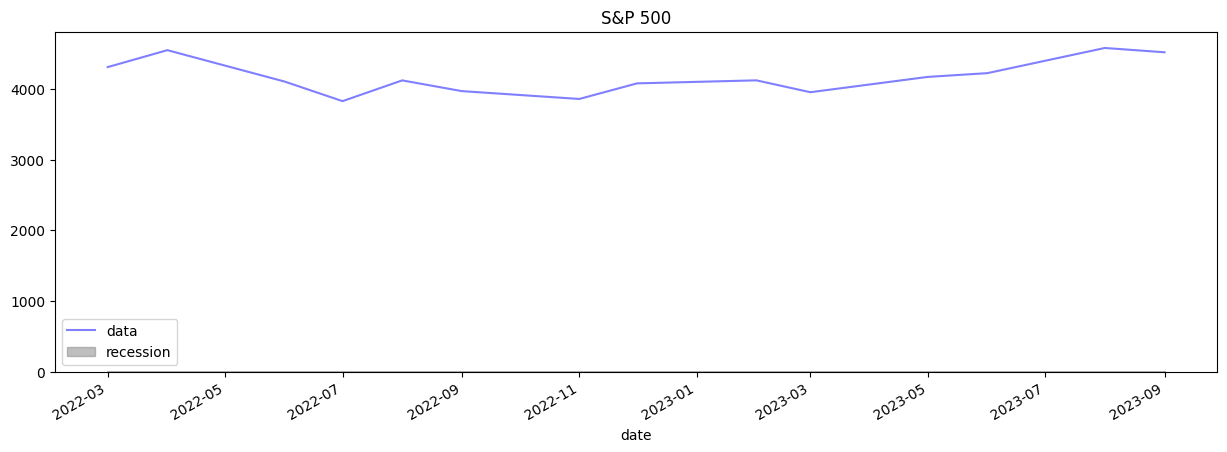

In [958]:
"""
Stock Market Decline: Stock markets are sensitive to economic conditions.
A prolonged period of declining stock prices may indicate investor pessimism about the economic outlook.
"""
plot_data("SP500", "S&P 500", years=2)

212.243 312.624
            recession
date                 
2019-12-01          0
2020-01-01          0
2020-02-01          0
2020-03-01          1
2020-04-01          1
2020-05-01          0
2020-06-01          0
2020-07-01          0
2020-08-01          0
2020-09-01          0
2020-10-01          0
2020-11-01          0
2020-12-01          0
2021-01-01          0
2021-02-01          0
2021-03-01          0
2021-04-01          0
2021-05-01          0
2021-06-01          0
2021-07-01          0
2021-08-01          0
2021-09-01          0
2021-10-01          0
2021-11-01          0
2021-12-01          0
2022-01-01          0
2022-02-01          0
2022-03-01          0
2022-04-01          0
2022-05-01          0
2022-06-01          0
2022-07-01          0
2022-08-01          0
2022-09-01          0
2022-10-01          0
2022-11-01          0
2022-12-01          0
2023-01-01          0
2023-02-01          0
2023-03-01          0
2023-04-01          0
2023-05-01          0
2023-06-01      

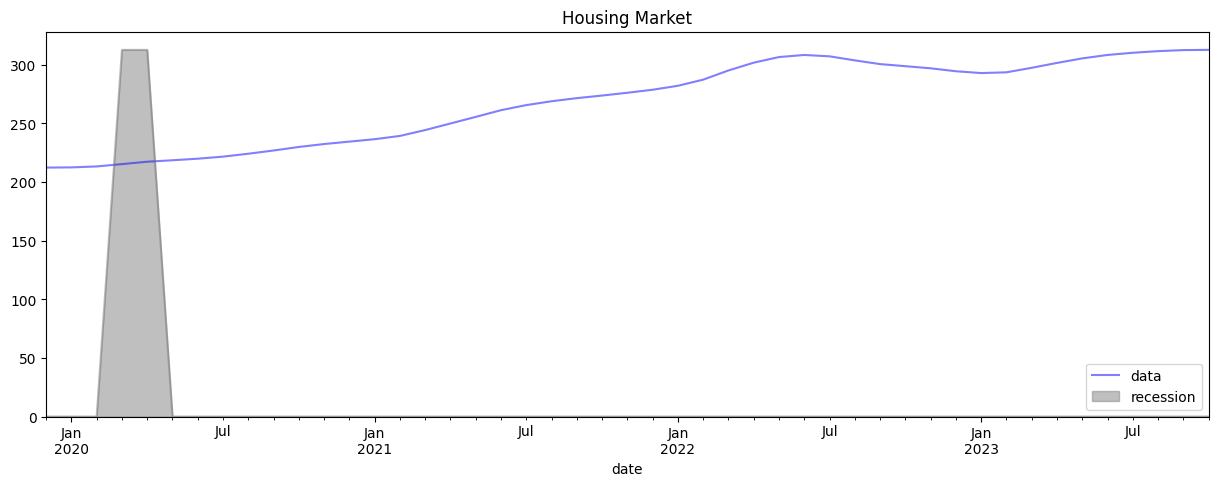

In [959]:
"""
Housing Market Slowdown: A recession often leads to a slowdown in the real estate market,
with declining home sales, falling prices, and increased foreclosures.
"""
plot_data("CSUSHPINSA", "Housing Market", years=4)

-32.4 83.6
            recession
date                 
1990-04-01          0
1990-07-01          0
1990-10-01          1
1991-01-01          1
1991-04-01          0
...               ...
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
2023-10-01          0

[135 rows x 1 columns]
            recession
date                 
1990-04-01        0.0
1990-07-01        0.0
1990-10-01       83.6
1991-01-01       83.6
1991-04-01        0.0
...               ...
2022-10-01        0.0
2023-01-01        0.0
2023-04-01        0.0
2023-07-01        0.0
2023-10-01        0.0

[135 rows x 1 columns]


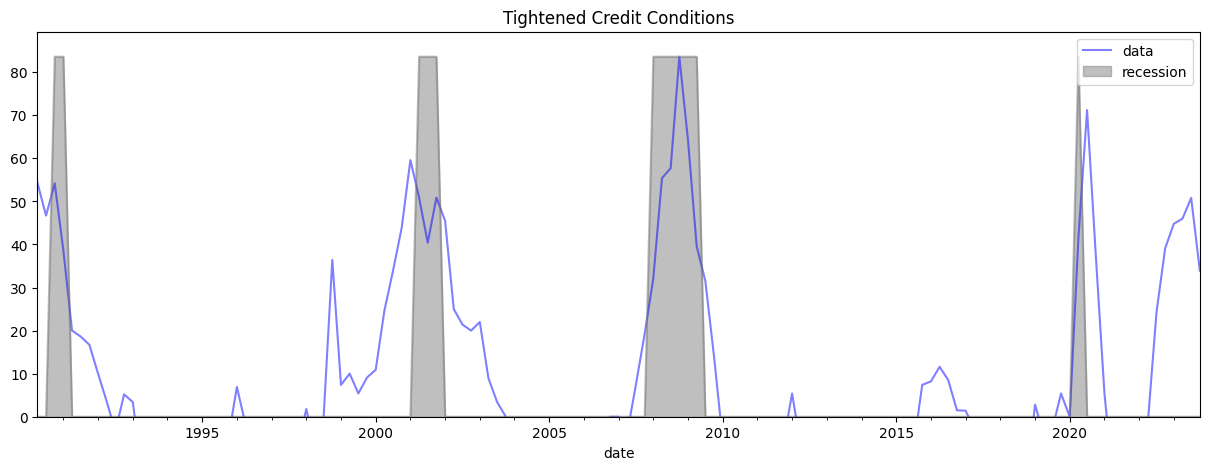

In [960]:
"""
Tightened Credit Conditions: Banks may become more cautious about lending during economic downturns,
leading to tightened credit conditions and reduced access to loans for businesses and consumers.
"""
plot_data("DRTSCILM", "Tightened Credit Conditions", years=50)

-0.88 0.41
            recession
date                 
2022-03-01          0
2022-04-01          0
2022-06-01          0
2022-07-01          0
2022-08-01          0
2022-09-01          0
2022-11-01          0
2022-12-01          0
2023-02-01          0
2023-03-01          0
2023-05-01          0
2023-06-01          0
2023-08-01          0
2023-09-01          0
            recession
date                 
2022-03-01          0
2022-04-01          0
2022-06-01          0
2022-07-01          0
2022-08-01          0
2022-09-01          0
2022-11-01          0
2022-12-01          0
2023-02-01          0
2023-03-01          0
2023-05-01          0
2023-06-01          0
2023-08-01          0
2023-09-01          0


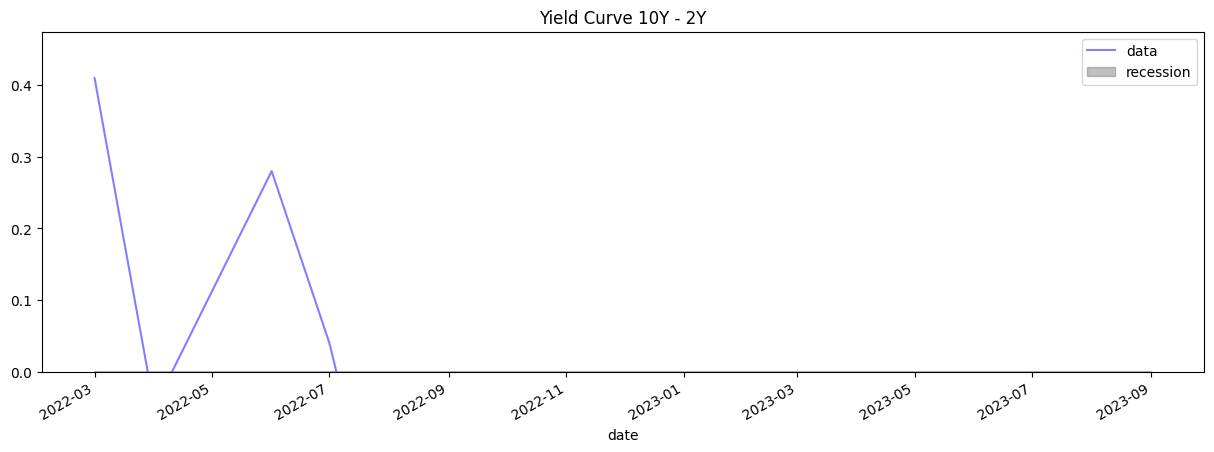

In [961]:
"""
Inverted Yield Curve: An inverted yield curve, where short-term interest rates are higher
than long-term rates has historically been a reliable predictor of economic recessions.
"""
plot_data("T10Y2Y", "Yield Curve 10Y - 2Y", years=2)

-1.89 -0.89
            recession
date                 
2023-03-01          0
2023-05-01          0
2023-06-01          0
2023-08-01          0
2023-09-01          0
            recession
date                 
2023-03-01          0
2023-05-01          0
2023-06-01          0
2023-08-01          0
2023-09-01          0


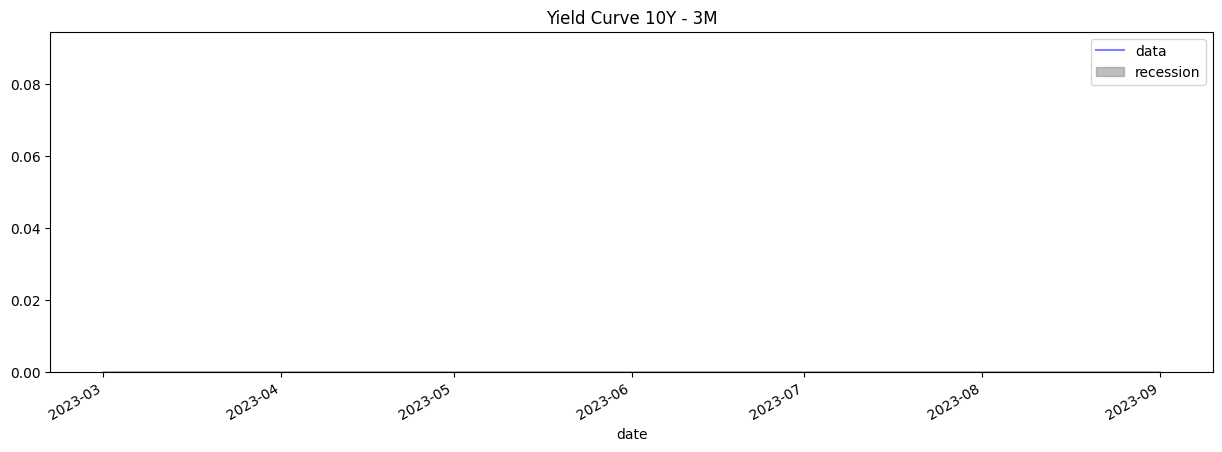

In [962]:
"""10-Year Treasury Constant Maturity Minus 3-Month Treasury Constant Maturity (T10Y3M)"""
plot_data("T10Y3M", "Yield Curve 10Y - 3M", years=1)

643.493 777.617
            recession
date                 
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
2023-10-01          0
            recession
date                 
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
2023-10-01          0


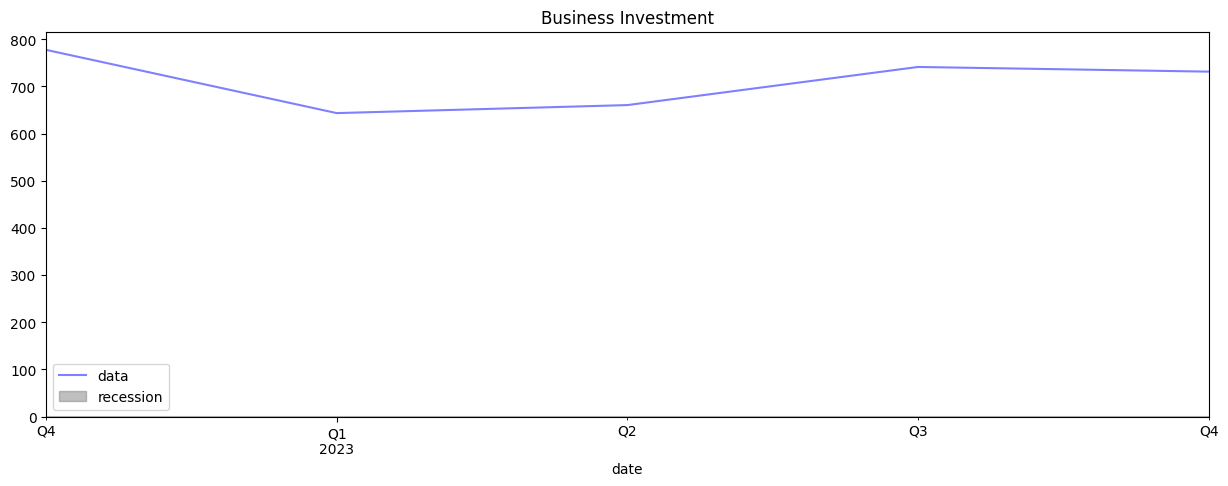

In [963]:
"""
Business Investment Decline: Companies may cut back on investments during a recession,
leading to a decline in capital expenditures and business expansion.
"""
plot_data("W790RC1Q027SBEA", "Business Investment", years=1)

1551.6 1590.9
            recession
date                 
2023-01-01          0
2023-02-01          0
2023-03-01          0
2023-04-01          0
2023-05-01          0
2023-06-01          0
2023-07-01          0
2023-08-01          0
2023-09-01          0
2023-10-01          0
            recession
date                 
2023-01-01          0
2023-02-01          0
2023-03-01          0
2023-04-01          0
2023-05-01          0
2023-06-01          0
2023-07-01          0
2023-08-01          0
2023-09-01          0
2023-10-01          0


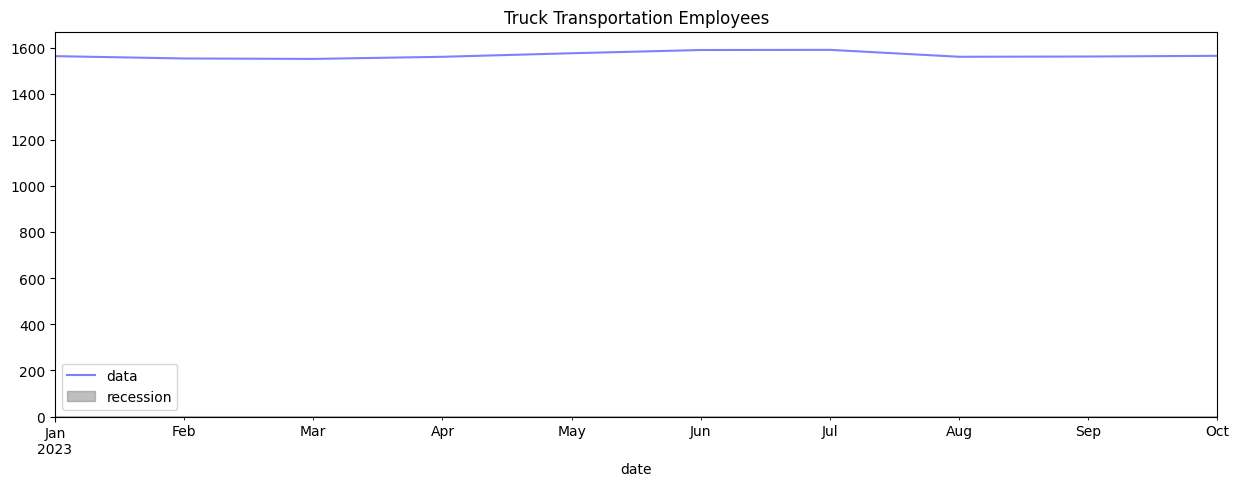

In [964]:
plot_data("CEU4348400001", "Truck Transportation Employees", years=1)

1.58 3.1
            recession
date                 
2021-10-01          0
2022-01-01          0
2022-04-01          0
2022-07-01          0
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
2023-10-01          0
            recession
date                 
2021-10-01          0
2022-01-01          0
2022-04-01          0
2022-07-01          0
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
2023-10-01          0


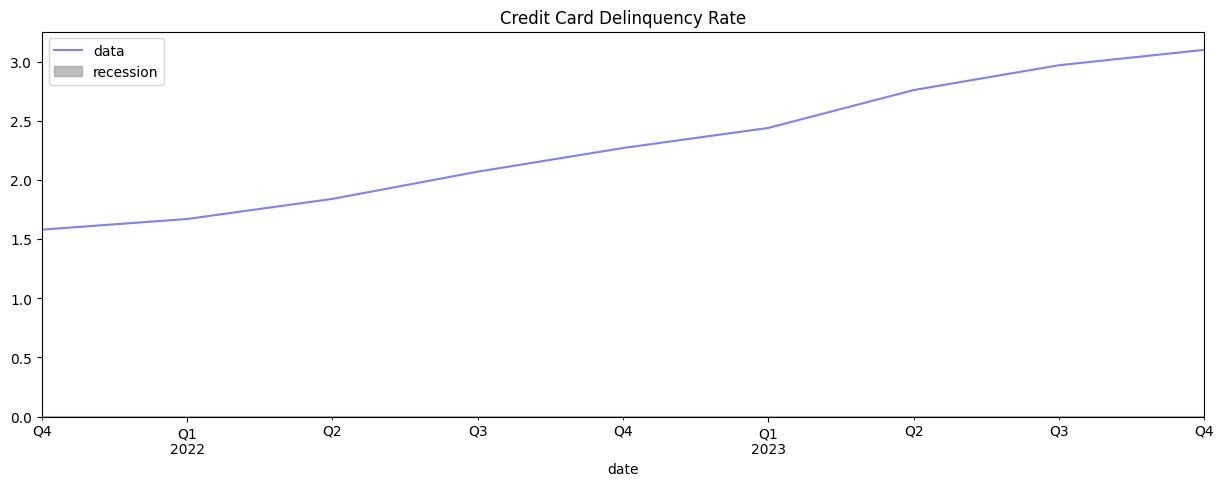

In [965]:
"""Delinquency Rate on Credit Card Loans, All Commercial Banks"""
plot_data("DRCCLACBS", "Credit Card Delinquency Rate", years=2)

4686.0 12027.0
            recession
date                 
2017-12-01          0
2018-01-01          0
2018-02-01          0
2018-03-01          0
2018-04-01          0
...               ...
2023-06-01          0
2023-07-01          0
2023-08-01          0
2023-09-01          0
2023-10-01          0

[71 rows x 1 columns]
            recession
date                 
2017-12-01        0.0
2018-01-01        0.0
2018-02-01        0.0
2018-03-01        0.0
2018-04-01        0.0
...               ...
2023-06-01        0.0
2023-07-01        0.0
2023-08-01        0.0
2023-09-01        0.0
2023-10-01        0.0

[71 rows x 1 columns]


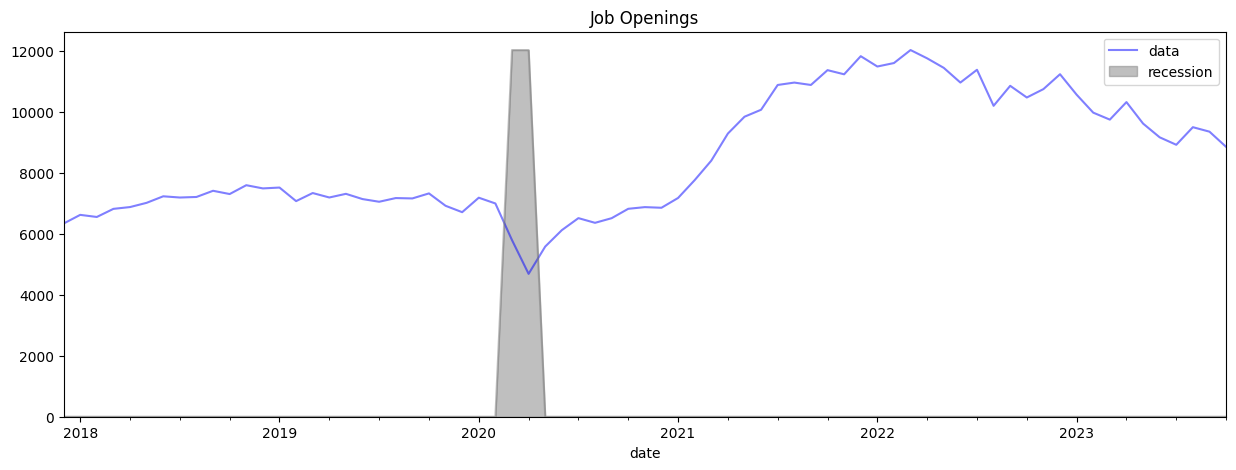

In [966]:
plot_data("JTSJOL", "Job Openings", years=6)

756.05 864.34
            recession
date                 
2022-07-01          0
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
            recession
date                 
2022-07-01          0
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0


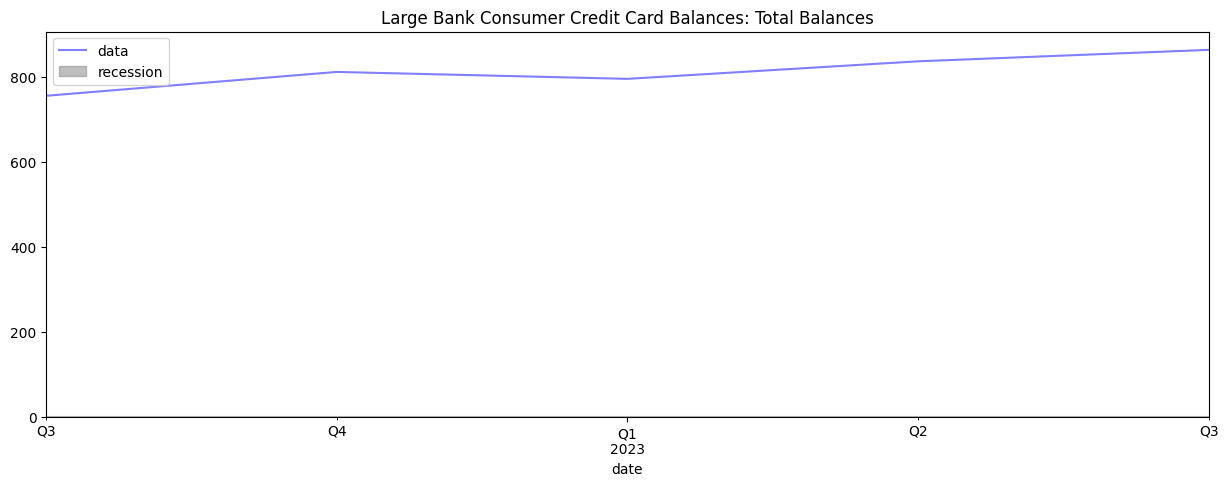

In [967]:
"""Large Bank Consumer Credit Card Balances: Total Balances (RCCCBBALTOT)"""
plot_data(
    "RCCCBBALTOT", "Large Bank Consumer Credit Card Balances: Total Balances", years=1
)

14.51 21.19
            recession
date                 
2021-11-01          0
2022-02-01          0
2022-05-01          0
2022-08-01          0
2022-11-01          0
2023-02-01          0
2023-05-01          0
2023-08-01          0
            recession
date                 
2021-11-01          0
2022-02-01          0
2022-05-01          0
2022-08-01          0
2022-11-01          0
2023-02-01          0
2023-05-01          0
2023-08-01          0


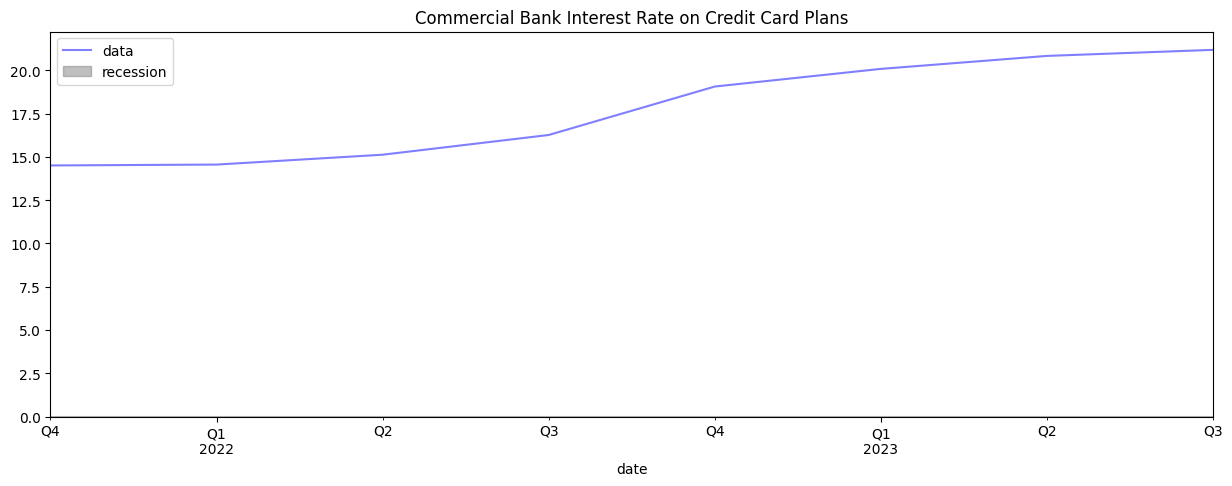

In [968]:
"""Commercial Bank Interest Rate on Credit Card Plans, All Accounts (TERMCBCCALLNS)"""
plot_data(
    "TERMCBCCALLNS", "Commercial Bank Interest Rate on Credit Card Plans", years=2
)

241.5 563.0
            recession
date                 
2019-01-01          0
2019-02-01          0
2019-03-01          0
2019-04-01          0
2019-05-01          0
2019-06-01          0
2019-07-01          0
2019-08-01          0
2019-09-01          0
2019-10-01          0
2019-11-01          0
2019-12-01          0
2020-01-01          0
2020-02-01          0
2020-03-01          1
2020-04-01          1
2020-05-01          0
2020-06-01          0
2020-07-01          0
2020-08-01          0
2020-09-01          0
2020-10-01          0
2020-11-01          0
2020-12-01          0
2021-01-01          0
2021-02-01          0
2021-03-01          0
2021-04-01          0
2021-05-01          0
2021-06-01          0
2021-07-01          0
2021-08-01          0
2021-09-01          0
2021-10-01          0
2021-11-01          0
2021-12-01          0
2022-01-01          0
2022-02-01          0
2022-03-01          0
2022-04-01          0
2022-05-01          0
2022-06-01          0
2022-07-01          

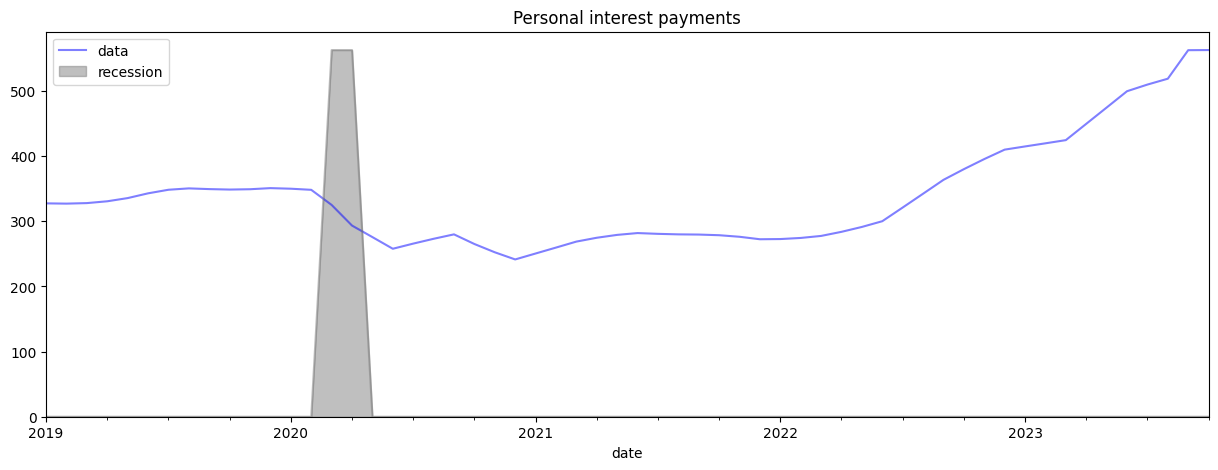

In [969]:
#  Personal interest payments (B069RC1)
plot_data("B069RC1", "Personal interest payments", years=5)

Other Indicators to Consider
- Net interest and miscellaneous payments on assets
- Personal Savings Rate

80.626 548.296
            recession
date                 
2013-10-01          0
2014-01-01          0
2014-04-01          0
2014-07-01          0
2014-10-01          0
2015-01-01          0
2015-04-01          0
2015-07-01          0
2015-10-01          0
2016-01-01          0
2016-04-01          0
2016-07-01          0
2016-10-01          0
2017-01-01          0
2017-04-01          0
2017-07-01          0
2017-10-01          0
2018-01-01          0
2018-04-01          0
2018-07-01          0
2018-10-01          0
2019-01-01          0
2019-04-01          0
2019-07-01          0
2019-10-01          0
2020-01-01          0
2020-04-01          1
2020-07-01          0
2020-10-01          0
2021-01-01          0
2021-04-01          0
2021-07-01          0
2021-10-01          0
2022-01-01          0
2022-04-01          0
2022-07-01          0
2022-10-01          0
2023-01-01          0
2023-04-01          0
2023-07-01          0
2023-10-01          0
            recession
date             

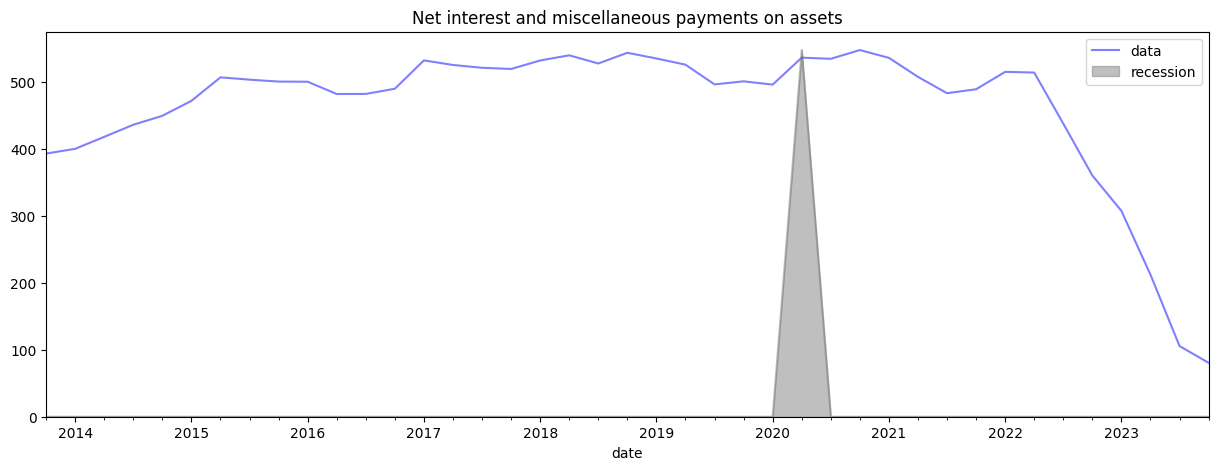

In [970]:
#  Net interest and miscellaneous payments on assets (W255RC1Q027SBEA)
plot_data(
    "W255RC1Q027SBEA", "Net interest and miscellaneous payments on assets", years=10
)

2.7 32.0
            recession
date                 
2018-01-01          0
2018-02-01          0
2018-03-01          0
2018-04-01          0
2018-05-01          0
...               ...
2023-06-01          0
2023-07-01          0
2023-08-01          0
2023-09-01          0
2023-10-01          0

[70 rows x 1 columns]
            recession
date                 
2018-01-01        0.0
2018-02-01        0.0
2018-03-01        0.0
2018-04-01        0.0
2018-05-01        0.0
...               ...
2023-06-01        0.0
2023-07-01        0.0
2023-08-01        0.0
2023-09-01        0.0
2023-10-01        0.0

[70 rows x 1 columns]


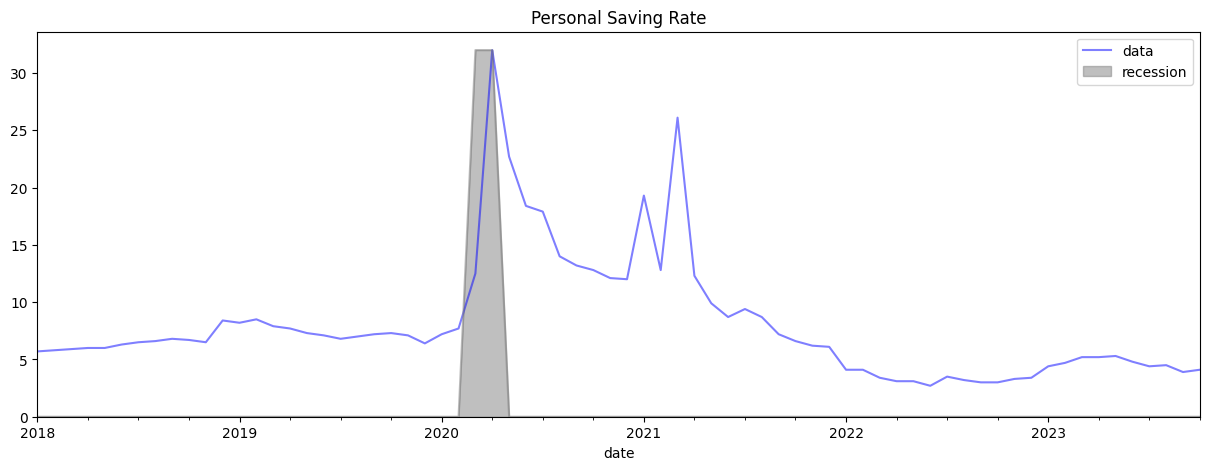

In [971]:
#  Personal Saving Rate (PSAVERT)
plot_data("PSAVERT", "Personal Saving Rate", years=6)

In [972]:
# LOOK AT THESE STOCKS
# In addition, certain individual stocks have outperformed during each of the past two U.S. recessions.
# Walmart Inc. (ticker: WMT), Abbott Laboratories (ABT) and Home Depot Inc. (HD)
# are just three examples of stocks that beat the S&P 500 in both 2008 and 2020.